In [1]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split

import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to C:\Users\Ananjay
[nltk_data]     Pampalli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
DATA_DIR = Path("../data")

columns = [
    "id", "label", "statement", "subject", "speaker",
    "speaker_job_title", "state_info", "party_affiliation",
    "barely_true_counts", "false_counts", "half_true_counts",
    "mostly_true_counts", "pants_on_fire_counts", "context"
]

train_df = pd.read_csv(DATA_DIR / "train.tsv", sep="\t", header=None, names=columns)
test_df  = pd.read_csv(DATA_DIR / "test.tsv", sep="\t", header=None, names=columns)
valid_df = pd.read_csv(DATA_DIR / "valid.tsv", sep="\t", header=None, names=columns)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("Valid Shape:", valid_df.shape)

Train Shape: (10240, 14)
Test Shape: (1267, 14)
Valid Shape: (1284, 14)


In [3]:
df = pd.concat([train_df, valid_df, test_df], axis=0).reset_index(drop=True)
print("Full Dataset Shape:", df.shape)
df.head()

Full Dataset Shape: (12791, 14)


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [4]:
label_map = {
    "pants-fire": 0,
    "false": 0,
    "barely-true": 0,
    "half-true": 1,
    "mostly-true": 1,
    "true": 1
}

df = df[["statement", "label"]].copy()
df["label"] = df["label"].map(label_map)

print(df["label"].value_counts())
df.head()

label
1    7134
0    5657
Name: count, dtype: int64


,statement,label
0,Says the Annies List political group supports ...,0
1,When did the decline of coal start? It started...,1
2,"Hillary Clinton agrees with John McCain ""by vo...",1
3,Health care reform legislation is likely to ma...,0
4,The economic turnaround started at the end of ...,1


In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["statement"].apply(clean_text)
df.head()

,statement,label,clean_text
0,Says the Annies List political group supports ...,0,says the annies list political group supports ...
1,When did the decline of coal start? It started...,1,when did the decline of coal start it started ...
2,"Hillary Clinton agrees with John McCain ""by vo...",1,hillary clinton agrees with john mccain by vot...
3,Health care reform legislation is likely to ma...,0,health care reform legislation is likely to ma...
4,The economic turnaround started at the end of ...,1,the economic turnaround started at the end of ...


In [6]:
df["text_len"] = df["clean_text"].apply(lambda x: len(x.split()))

print("Missing Values:\n", df.isnull().sum())
print("\nAverage Text Length:", df["text_len"].mean())
print("Max Text Length:", df["text_len"].max())
print("Min Text Length:", df["text_len"].min())

Missing Values:
 statement     0
label         0
clean_text    0
text_len      0
dtype: int64

Average Text Length: 17.97326245016027
Max Text Length: 464
Min Text Length: 2


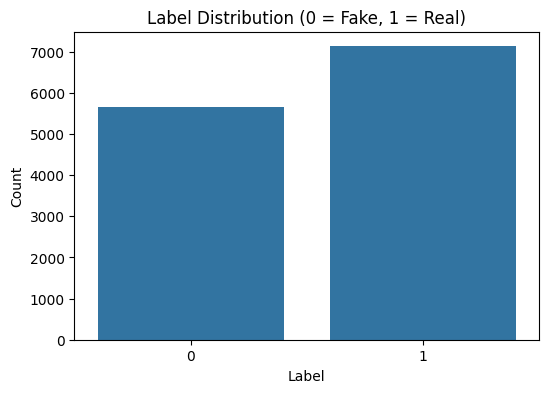

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Label Distribution (0 = Fake, 1 = Real)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

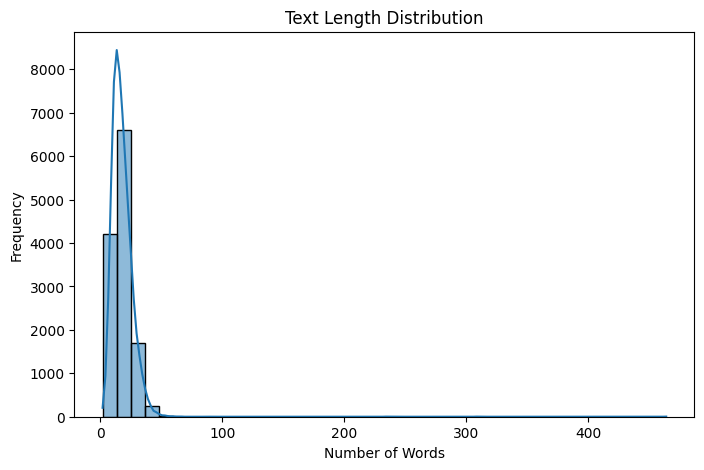

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_len"], bins=40, kde=True)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [9]:
df = df[["clean_text", "label"]]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,clean_text,label
0,in the event of a us strike on syria the russi...,0
1,to give the proposed economic stimulus plan so...,1
2,its warmer on mars than it is in parts of the ...,0
3,the health insurance plan that members of cong...,1
4,hes promising four more years of an administra...,0


In [10]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train Size:", len(train_texts))
print("Test Size:", len(test_texts))

Train Size: 10232
Test Size: 2559


In [11]:
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

train_processed = pd.DataFrame({
    "text": train_texts.values,
    "label": train_labels.values
})

test_processed = pd.DataFrame({
    "text": test_texts.values,
    "label": test_labels.values
})

train_processed.to_csv(OUTPUT_DIR / "train_processed.csv", index=False)
test_processed.to_csv(OUTPUT_DIR / "test_processed.csv", index=False)

print("Saved processed files to outputs/")

Saved processed files to outputs/
